In [1]:
import os
import sys
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoConfig, AutoTokenizer
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Add parent directory to path so we can import from /src
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Import the EXACT class from your source code
from src.mtl_model import RobertaMTL_Advanced 
from src.config import DEVICE 

In [2]:
# Configuration
MODEL_FILE = "tuned_mtl_seed7_lam0.2.pt"
MODEL_PATH = os.path.join(parent_dir, "models", "mtl_models", MODEL_FILE)

def get_mtl_preds_with_confidence(model, tokenizer, df, batch_size=32):
    """Runs inference for both Sentiment and Sarcasm tasks."""
    model.eval()
    texts = df['text'].tolist()
    results = {'pred': [], 'conf': [], 'sarc_pred': []}

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Running MTL Inference"):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, 
                               padding=True, max_length=128).to(DEVICE)           

            # Predict Sentiment
            out_sent = model(inputs['input_ids'], inputs['attention_mask'], task='sentiment')
            probs_sent = torch.nn.functional.softmax(out_sent.logits, dim=-1)
            conf_sent, pred_sent = torch.max(probs_sent, dim=-1)
        
            # Predict Sarcasm (The Helper Task)
            out_sarc = model(inputs['input_ids'], inputs['attention_mask'], task='sarcasm')
            pred_sarc = torch.argmax(out_sarc.logits, dim=-1)
           

            results['pred'].extend(pred_sent.cpu().numpy())
            results['conf'].extend(conf_sent.cpu().numpy())
            results['sarc_pred'].extend(pred_sarc.cpu().numpy())

    return results

### Error Analysis on Test set

In [3]:
FORCE_RERUN = False
PRED_FILE_PATH = "../outputs/predictions/mtl_test_preds.csv"
if not os.path.exists(PRED_FILE_PATH) or FORCE_RERUN:
    # Load Model
    config = AutoConfig.from_pretrained("roberta-base")
    tokenizer = AutoTokenizer.from_pretrained("roberta-base")
    model = RobertaMTL_Advanced("roberta-base", config, dropout_prob=0.15)
    # Pour the 'Soul' (State Dict) into the 'Body'
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    # Load Data
    df_test = pd.read_csv(os.path.join(parent_dir, "data/raw/sentiment_test.csv"))
    # Run Predictions
    preds_dict = get_mtl_preds_with_confidence(model, tokenizer, df_test)
     # Append to DataFrame
    df_test['pred'] = preds_dict['pred']
    df_test['confidence'] = preds_dict['conf']
    df_test['pred_sarcasm'] = preds_dict['sarc_pred']
    df_test['is_correct'] = df_test['label'] == df_test['pred']
    df_test['word_count'] = df_test['text'].apply(lambda x: len(str(x).split()))
    # Save
    os.makedirs(os.path.dirname(PRED_FILE_PATH), exist_ok=True)
    df_test.to_csv(PRED_FILE_PATH, index=False)
    print(f"Saved results to {PRED_FILE_PATH}")
else:
    print(f"Loading existing predictions from {PRED_FILE_PATH}")
    df_test = pd.read_csv(PRED_FILE_PATH)

Loading existing predictions from ../outputs/predictions/mtl_test_preds.csv


In [4]:
# Load Baseline predictions
BASELINE_TEST_PATH = "../outputs/predictions/baseline_test_preds.csv"
df_base_test = pd.read_csv(BASELINE_TEST_PATH)
# Merge MTL and Baseline dataframes on the 'text' column to compare them side-by-side
# We rename columns to keep it clear: _mtl and _base
df_compare = pd.merge(
    df_test[['text', 'label', 'pred', 'confidence', 'pred_sarcasm']], 
    df_base_test[['text', 'pred', 'confidence']], 
    on='text', 
    suffixes=('_mtl', '_base')
)
df_compare['is_correct_mtl'] = df_compare['label'] == df_compare['pred_mtl']
df_compare['is_correct_base'] = df_compare['label'] == df_compare['pred_base']


In [5]:
print("Classification Report")
print(classification_report(df_test['label'], df_test['pred'], target_names=['Negative', 'Neutral', 'Positive']))

Classification Report
              precision    recall  f1-score   support

    Negative       0.69      0.81      0.74      3972
     Neutral       0.76      0.63      0.69      5937
    Positive       0.66      0.76      0.71      2375

    accuracy                           0.71     12284
   macro avg       0.70      0.73      0.71     12284
weighted avg       0.72      0.71      0.71     12284



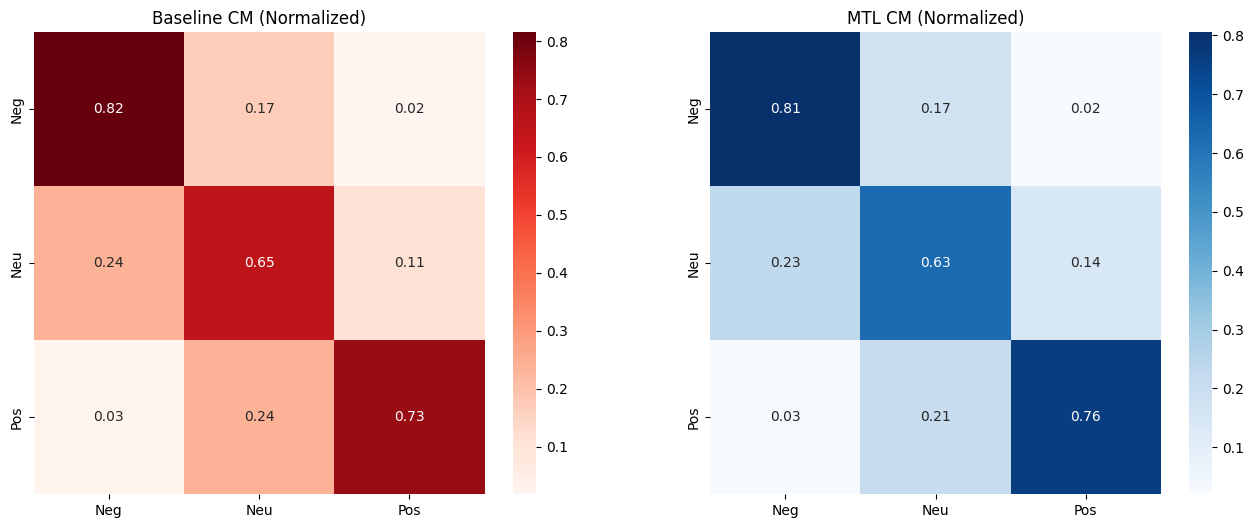

In [6]:
# --- Confusion Matrix Visualization ---
fig, axes = plt.subplots(1,2,figsize=(16,6))
cm_base = confusion_matrix(df_compare['label'], df_compare['pred_base'], normalize='true')
sns.heatmap(cm_base, annot=True, fmt='.2f', cmap='Reds', ax=axes[0],
            xticklabels=['Neg','Neu','Pos'], yticklabels=['Neg','Neu','Pos'])
axes[0].set_title("Baseline CM (Normalized)")

cm_mtl = confusion_matrix(df_compare['label'], df_compare['pred_mtl'], normalize='true')
sns.heatmap(cm_mtl, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=['Neg','Neu','Pos'], yticklabels=['Neg','Neu','Pos'])
axes[1].set_title("MTL CM (Normalized)")
plt.show()

In [7]:
# --- Comparative Rescue & Regression Analysis ---
rescues = df_compare[(df_compare['is_correct_mtl']==True) & (df_compare['is_correct_base']==False)]
regressions = df_compare[(df_compare['is_correct_mtl']==False) & (df_compare['is_correct_base']==True)]

print(f"MTL Rescues: {len(rescues)}, Regressions: {len(regressions)}")

# Sarcasm effect
print(f"Sarcasm in Rescues: {rescues['pred_sarcasm'].mean()*100:.1f}%")
print(f"Sarcasm in All: {df_compare['pred_sarcasm'].mean()*100:.1f}%")


MTL Rescues: 568, Regressions: 677
Sarcasm in Rescues: 16.9%
Sarcasm in All: 14.5%


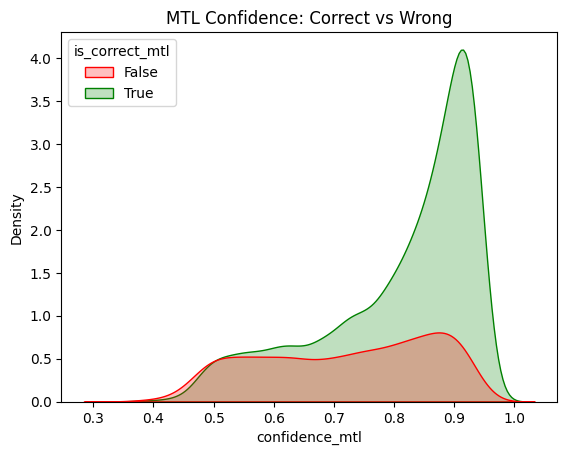

In [8]:
# --- Confidence vs Correctness ---
sns.kdeplot(data=df_compare, x='confidence_mtl', hue='is_correct_mtl', fill=True, palette={True:'green', False:'red'})
plt.title("MTL Confidence: Correct vs Wrong")
plt.show()

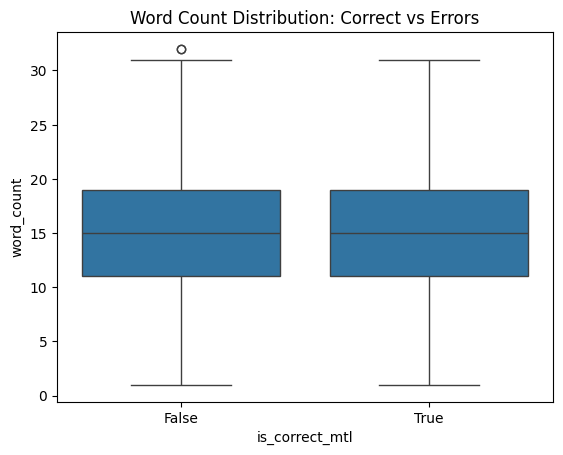

In [9]:
# --- Text Length vs Errors ---
df_compare['word_count'] = df_compare['text'].apply(lambda x: len(str(x).split()))
sns.boxplot(x='is_correct_mtl', y='word_count', data=df_compare)
plt.title("Word Count Distribution: Correct vs Errors")
plt.show()

In [10]:
# --- Error Type Categorization ---
errors = df_compare[df_compare['is_correct_mtl']==False].copy()
polarity_flips = errors[((errors['label']==0)&(errors['pred_mtl']==2)) | ((errors['label']==2)&(errors['pred_mtl']==0))]
under_sensitive = errors[(errors['label'].isin([0,2])) & (errors['pred_mtl']==1)]
over_sensitive = errors[(errors['label']==1) & (errors['pred_mtl'].isin([0,2]))]

print(f"Polarity Flips: {len(polarity_flips)}")
print(f"Under-sensitive: {len(under_sensitive)}")
print(f"Over-sensitive: {len(over_sensitive)}")


Polarity Flips: 143
Under-sensitive: 1191
Over-sensitive: 2221


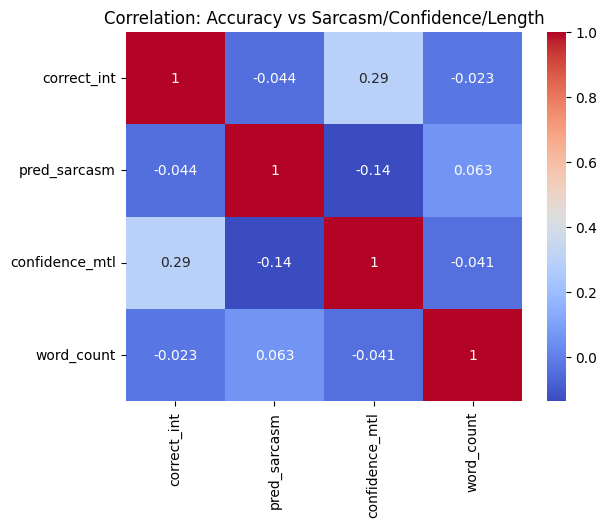

In [11]:
# --- Correlation Analysis ---
df_compare['correct_int'] = df_compare['is_correct_mtl'].astype(int)
corr_matrix = df_compare[['correct_int','pred_sarcasm','confidence_mtl','word_count']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation: Accuracy vs Sarcasm/Confidence/Length")
plt.show()

In [12]:
# Compare Sarcasm rate in Errors vs. Successes
print(f"Sarcasm rate in WRONG predictions: {df_compare[df_compare['correct_int']==0]['pred_sarcasm'].mean():.2%}")
print(f"Sarcasm rate in CORRECT predictions: {df_compare[df_compare['correct_int']==1]['pred_sarcasm'].mean():.2%}")

Sarcasm rate in WRONG predictions: 16.96%
Sarcasm rate in CORRECT predictions: 13.52%


### Error Analysis on Golden set

In [13]:
# --- 1. GOLDEN SET INFERENCE & CACHING ---
GOLDEN_PRED_FILE = "../outputs/predictions/mtl_golden_preds.csv"
GOLDEN_DATA_PATH = os.path.join(parent_dir, "data/processed/golden_set_clean.csv")

if not os.path.exists(GOLDEN_PRED_FILE) or FORCE_RERUN:
    print(f"Running Inference on Golden Set...")
    # Load Model
    config = AutoConfig.from_pretrained("roberta-base")
    tokenizer = AutoTokenizer.from_pretrained("roberta-base")
    model = RobertaMTL_Advanced("roberta-base", config, dropout_prob=0.15)
    # Pour the 'Soul' (State Dict) into the 'Body'
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    # Ensure model is loaded (from previous block)
    df_gold = pd.read_csv(GOLDEN_DATA_PATH)
    
    preds_dict_gold = get_mtl_preds_with_confidence(model, tokenizer, df_gold)
    
    df_gold['pred'] = preds_dict_gold['pred']
    df_gold['confidence'] = preds_dict_gold['conf']
    df_gold['pred_sarcasm'] = preds_dict_gold['sarc_pred']
    df_gold['is_correct'] = df_gold['label'] == df_gold['pred']
    df_gold['word_count'] = df_gold['text'].apply(lambda x: len(str(x).split()))
    
    df_gold.to_csv(GOLDEN_PRED_FILE, index=False)
    print(f"Saved Golden results to {GOLDEN_PRED_FILE}")
else:
    print(f"Loading existing Golden predictions from {GOLDEN_PRED_FILE}")
    df_gold = pd.read_csv(GOLDEN_PRED_FILE)

Loading existing Golden predictions from ../outputs/predictions/mtl_golden_preds.csv


In [15]:
BASELINE_GOLD_PATH = "../outputs/predictions/baseline_golden_preds.csv"
df_mtl = pd.read_csv(GOLDEN_PRED_FILE)
df_base = pd.read_csv(BASELINE_GOLD_PATH)
# Merge MTL & Baseline predictions
df_gold_compare = pd.merge(
    df_mtl[['text','label','pred','confidence','pred_sarcasm','word_count']],
    df_base[['text','pred','confidence']],
    on='text',
    suffixes=('_mtl','_base')
)

# Flags for correctness
df_gold_compare['is_correct_mtl'] = df_gold_compare['label'] == df_gold_compare['pred_mtl']
df_gold_compare['is_correct_base'] = df_gold_compare['label'] == df_gold_compare['pred_base']


GOLDEN SET CLASSIFICATION REPORT (MTL)
              precision    recall  f1-score   support

         Neg       1.00      0.35      0.52        40
         Neu       0.69      0.85      0.76        13
         Pos       0.57      0.97      0.72        33

    accuracy                           0.66        86
   macro avg       0.75      0.72      0.67        86
weighted avg       0.79      0.66      0.63        86



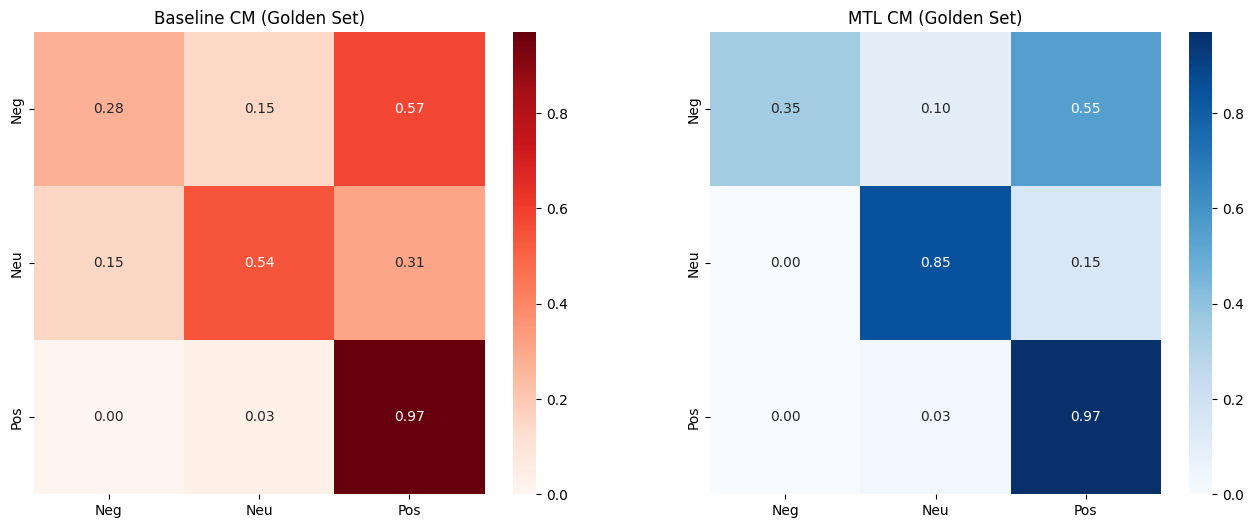

In [16]:
# === 1. OVERALL PERFORMANCE ===
print("GOLDEN SET CLASSIFICATION REPORT (MTL)")
print(classification_report(df_gold_compare['label'], df_gold_compare['pred_mtl'], target_names=['Neg','Neu','Pos']))

# Confusion matrix
fig, ax = plt.subplots(1,2, figsize=(16,6))
cm_base = confusion_matrix(df_gold_compare['label'], df_gold_compare['pred_base'], normalize='true')
sns.heatmap(cm_base, annot=True, fmt='.2f', cmap='Reds', ax=ax[0], xticklabels=['Neg','Neu','Pos'], yticklabels=['Neg','Neu','Pos'])
ax[0].set_title("Baseline CM (Golden Set)")

cm_mtl = confusion_matrix(df_gold_compare['label'], df_gold_compare['pred_mtl'], normalize='true')
sns.heatmap(cm_mtl, annot=True, fmt='.2f', cmap='Blues', ax=ax[1], xticklabels=['Neg','Neu','Pos'], yticklabels=['Neg','Neu','Pos'])
ax[1].set_title("MTL CM (Golden Set)")
plt.show()


In [ ]:
# === 2. MTL RESCUES & REGRESSIONS ===
rescues = df_gold_compare[(df_gold_compare['is_correct_mtl']==True) & (df_gold_compare['is_correct_base']==False)]
regressions = df_gold_compare[(df_gold_compare['is_correct_mtl']==False) & (df_gold_compare['is_correct_base']==True)]

print(f"MTL Rescues: {len(rescues)} / {len(df_gold_compare)} samples")
print(f"MTL Regressions: {len(regressions)} / {len(df_gold_compare)} samples")


MTL Rescues: 7 / 86 samples
MTL Regressions: 0 / 86 samples


In [ ]:
# === 3. SARCASTIC INSIGHTS ===
# Since all golden samples are sarcastic, check how sarcasm prediction helped
rescues_sarc = rescues[rescues['pred_sarcasm']==1]
print(f"Sarcasm detected in Rescues: {len(rescues_sarc)} / {len(rescues)} ({len(rescues_sarc)/len(rescues)*100:.1f}%)")


Sarcasm detected in Rescues: 4 / 7 (57.1%)


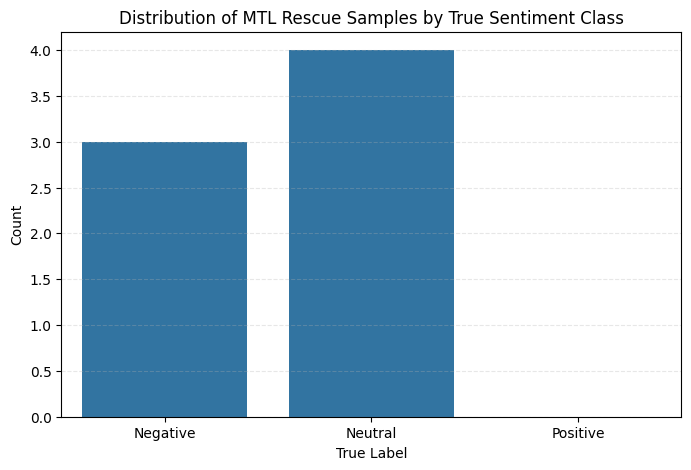

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

rescues = df_gold_compare[
    (df_gold_compare['is_correct_mtl']==True) &
    (df_gold_compare['is_correct_base']==False)
].copy()

label_map = {0:'Negative',1:'Neutral',2:'Positive'}
rescues['label_name'] = rescues['label'].map(label_map)

plt.figure(figsize=(8,5))
sns.countplot(data=rescues, x='label_name', order=['Negative','Neutral','Positive'])

plt.title("Distribution of MTL Rescue Samples by True Sentiment Class")
plt.xlabel("True Label")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

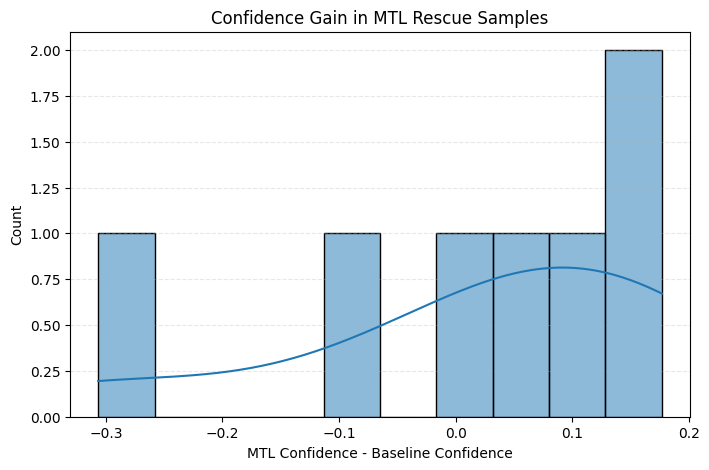

                                                 text  confidence_base  \
44         "Leg day tomorrow &gt;&gt;&gt;&gt;&gt;&gt;         0.509412   
29  "John Fox kicking the field goal on 4th and 1 ...         0.512969   
16  #Snowpocalypse update: Every city in between M...         0.529822   
45  I only have one of the most important tests of...         0.619543   
84  Oh is there really a 2 hour delay tomorrow oh ...         0.567356   
59  Your inspirational quotes on twitter/Feb never...         0.496764   
41  If this year is anything like last year, KI's ...         0.780136   

    confidence_mtl  confidence_gain  
44        0.686216         0.176803  
29        0.653546         0.140577  
16        0.650013         0.120191  
45        0.691219         0.071676  
84        0.585576         0.018220  
59        0.423102        -0.073663  
41        0.473623        -0.306514  


In [18]:
rescues['confidence_gain'] = rescues['confidence_mtl'] - rescues['confidence_base']

plt.figure(figsize=(8,5))
sns.histplot(rescues['confidence_gain'], bins=10, kde=True)

plt.title("Confidence Gain in MTL Rescue Samples")
plt.xlabel("MTL Confidence - Baseline Confidence")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print(rescues[['text','confidence_base','confidence_mtl','confidence_gain']].sort_values('confidence_gain', ascending=False))

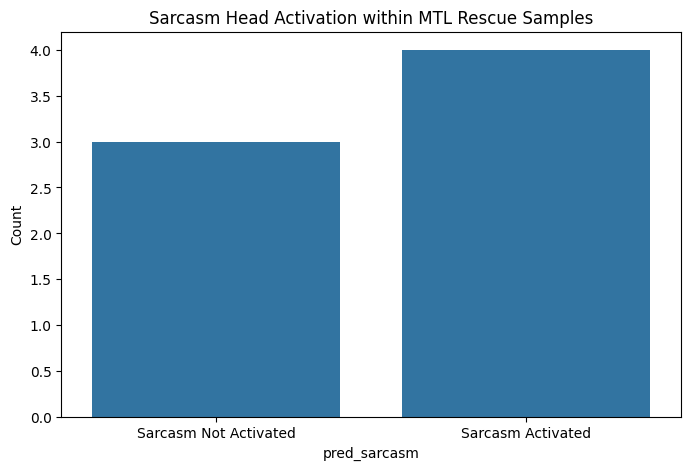

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rescues,
    x='pred_sarcasm'
)

plt.xticks([0,1], ['Sarcasm Not Activated','Sarcasm Activated'])
plt.title("Sarcasm Head Activation within MTL Rescue Samples")
plt.ylabel("Count")
plt.show()

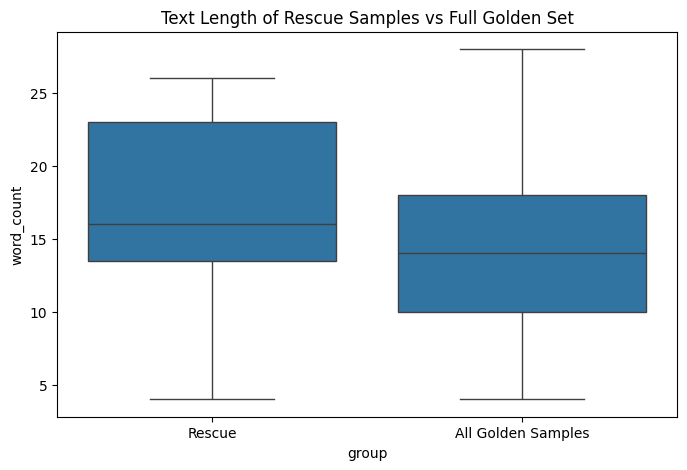

In [20]:
rescues['group'] = 'Rescue'
df_gold_compare['group'] = 'All Golden Samples'

plot_df = pd.concat([
    rescues[['word_count','group']],
    df_gold_compare[['word_count','group']]
])

plt.figure(figsize=(8,5))
sns.boxplot(data=plot_df, x='group', y='word_count')

plt.title("Text Length of Rescue Samples vs Full Golden Set")
plt.show()

In [21]:
display(
    rescues[['text','label','pred_base','pred_mtl','pred_sarcasm']]
)

,text,label,pred_base,pred_mtl,pred_sarcasm
16,#Snowpocalypse update: Every city in between M...,1,0,1,0
29,"""John Fox kicking the field goal on 4th and 1 ...",1,0,1,0
41,"If this year is anything like last year, KI's ...",1,2,1,0
44,"""Leg day tomorrow &gt;&gt;&gt;&gt;&gt;&gt;",1,2,1,1
45,I only have one of the most important tests of...,0,2,0,1
59,Your inspirational quotes on twitter/Feb never...,0,2,0,1
84,Oh is there really a 2 hour delay tomorrow oh ...,0,1,0,1


In [22]:
print(rescues['label'].value_counts(normalize=True))
print(df_gold_compare['label'].value_counts(normalize=True))

label
1    0.571429
0    0.428571
Name: proportion, dtype: float64
label
0    0.465116
2    0.383721
1    0.151163
Name: proportion, dtype: float64


In [ ]:
# === 4. ERROR CATEGORIZATION ===
errors = df_gold_compare[df_gold_compare['is_correct_mtl']==False].copy()

# Polarity flips: Neg <-> Pos
polarity_flips = errors[((errors['label']==0)&(errors['pred_mtl']==2)) | ((errors['label']==2)&(errors['pred_mtl']==0))]

# Under-sensitive: True Pos/Neg predicted as Neutral
under_sensitive = errors[(errors['label'].isin([0,2])) & (errors['pred_mtl']==1)]

# Over-sensitive: Neutral predicted as Pos/Neg
over_sensitive = errors[(errors['label']==1) & (errors['pred_mtl'].isin([0,2]))]

print(f"Polarity Flips: {len(polarity_flips)} ({len(polarity_flips)/len(df_gold_compare)*100:.2f}%)")
print(f"Under-sensitive: {len(under_sensitive)} ({len(under_sensitive)/len(df_gold_compare)*100:.2f}%)")
print(f"Over-sensitive: {len(over_sensitive)} ({len(over_sensitive)/len(df_gold_compare)*100:.2f}%)")

# Show top examples for polarity flips
print("\nTOP POLARITY FLIPS (Potential Sarcasm or Negation Failures):")
display(polarity_flips[['text','label','pred_mtl','confidence_mtl']].head(5))


Polarity Flips: 22 (25.58%)
Under-sensitive: 5 (5.81%)
Over-sensitive: 2 (2.33%)

TOP POLARITY FLIPS (Potential Sarcasm or Negation Failures):


,text,label,pred_mtl,confidence_mtl
0,"""@MetroNorth wall to wall people on the platform at South Norwalk waiting for the 8:08. Thanks for the Sat. Sched. Great sense",0,2,0.535516
2,"""RT @katie_rohaley: School on Monday is just gonna be a great time",0,2,0.941169
3,"Thanks manager for putting me on the schedule for Sunday""",0,2,0.876568
7,"it's supposed to snow from midnight tonight until 6pm tomorrow? oh well that's friggin awesome""",0,2,0.922921
9,"Spending my Saturday getting my car serviced is definitely the most enjoyable thing I could do with my time.""",0,2,0.951033


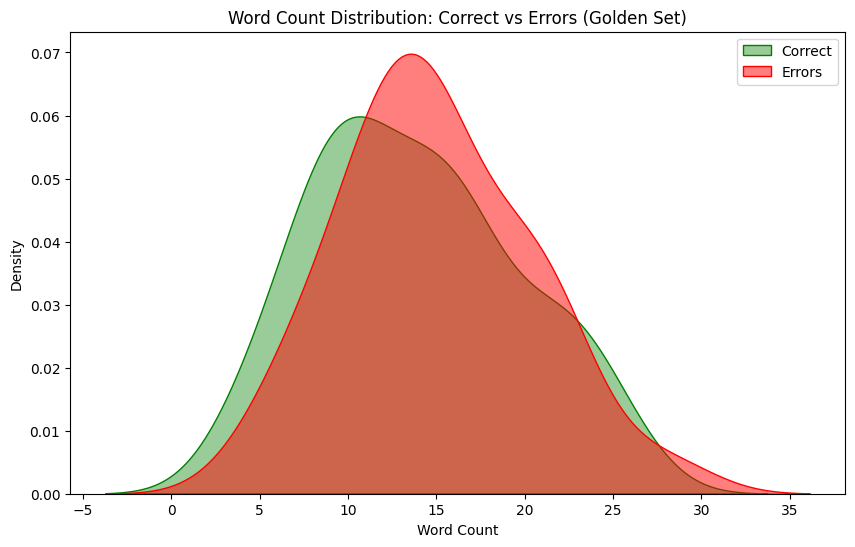

Avg Length: Correct=13.9, Errors=14.9


In [ ]:
# === 5. TEXT LENGTH VS ERRORS ===
plt.figure(figsize=(10,6))
sns.kdeplot(df_gold_compare[df_gold_compare['is_correct_mtl']==True]['word_count'], fill=True, label='Correct', color='green', alpha=0.4)
sns.kdeplot(df_gold_compare[df_gold_compare['is_correct_mtl']==False]['word_count'], fill=True, label='Errors', color='red', alpha=0.5)
plt.title("Word Count Distribution: Correct vs Errors (Golden Set)")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.legend()
plt.show()

# Statistics
avg_len_correct = df_gold_compare[df_gold_compare['is_correct_mtl']==True]['word_count'].mean()
avg_len_error = df_gold_compare[df_gold_compare['is_correct_mtl']==False]['word_count'].mean()
print(f"Avg Length: Correct={avg_len_correct:.1f}, Errors={avg_len_error:.1f}")


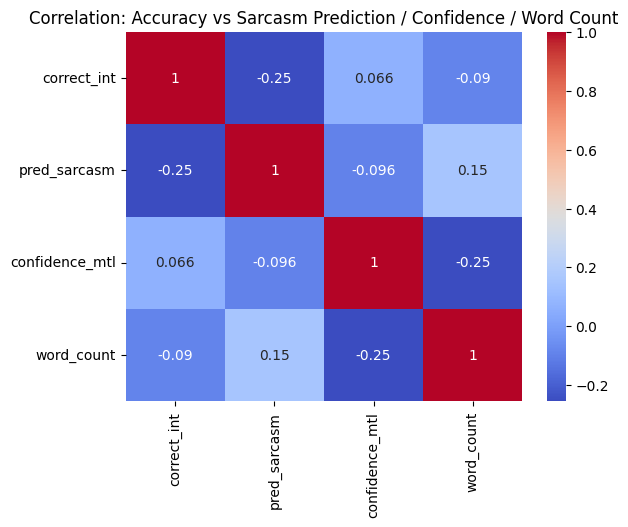

In [ ]:
# === 6. CORRELATION ANALYSIS ===
df_gold_compare['correct_int'] = df_gold_compare['is_correct_mtl'].astype(int)
corr_matrix = df_gold_compare[['correct_int','pred_sarcasm','confidence_mtl','word_count']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation: Accuracy vs Sarcasm Prediction / Confidence / Word Count")
plt.show()

In [ ]:
# === 7. HIGH-CONFIDENCE ERRORS ===
high_conf_errors = errors[errors['confidence_mtl']>0.85]
print(f"High-confidence errors (>85% confidence): {len(high_conf_errors)}")
display(high_conf_errors[['text','label','pred_mtl','confidence_mtl','pred_sarcasm']].head(5))


High-confidence errors (>85% confidence): 15


,text,label,pred_mtl,confidence_mtl,pred_sarcasm
2,"""RT @katie_rohaley: School on Monday is just gonna be a great time",0,2,0.941169,0
3,"Thanks manager for putting me on the schedule for Sunday""",0,2,0.876568,1
6,"""@rob_yost -Hashtags can express humor, excitement- ex: """"Just found out my mom is my teacher. #awkward"""" or """"It's Monday! #excited """"",1,2,0.916436,0
7,"it's supposed to snow from midnight tonight until 6pm tomorrow? oh well that's friggin awesome""",0,2,0.922921,1
9,"Spending my Saturday getting my car serviced is definitely the most enjoyable thing I could do with my time.""",0,2,0.951033,1


In [ ]:
# === 8. QUALITATIVE INSPECTION OF RESCUES ===
top_rescues = rescues.sort_values(by='confidence_mtl', ascending=False)
print("\nTOP RESCUES BY CONFIDENCE (Sarcasm Detected):")
display(top_rescues[top_rescues['pred_sarcasm']==1][['text','label','pred_base','pred_mtl','confidence_mtl']])


TOP RESCUES BY CONFIDENCE (Sarcasm Detected):


,text,label,pred_base,pred_mtl,confidence_mtl
45,"I only have one of the most important tests of my career Monday. Of course I can do your shit instead of mine! at its finest""",0,2,0,0.691219
44,"""Leg day tomorrow &gt;&gt;&gt;&gt;&gt;&gt;",1,2,1,0.686216
84,"Oh is there really a 2 hour delay tomorrow oh didn't know so keep posting it""",0,1,0,0.585576
59,"Your inspirational quotes on twitter/Feb never really got to me. But oh damn ur pics of them on IG have truly inspired me. #idiots""",0,2,0,0.423102
